Dataset shape: (1001, 7)

Column types:
age          int64
balance      int64
day          int64
duration     int64
job         object
marital     object
y           object
dtype: object

Central tendency (numeric):


,mean,median,mode
age,42.586414,42.0,40
balance,580.420579,165.0,0
day,5.874126,6.0,6
duration,269.020979,202.0,144



Outlier counts by numeric column (IQR rule):


,outlier_count
age,0
balance,110
day,0
duration,75


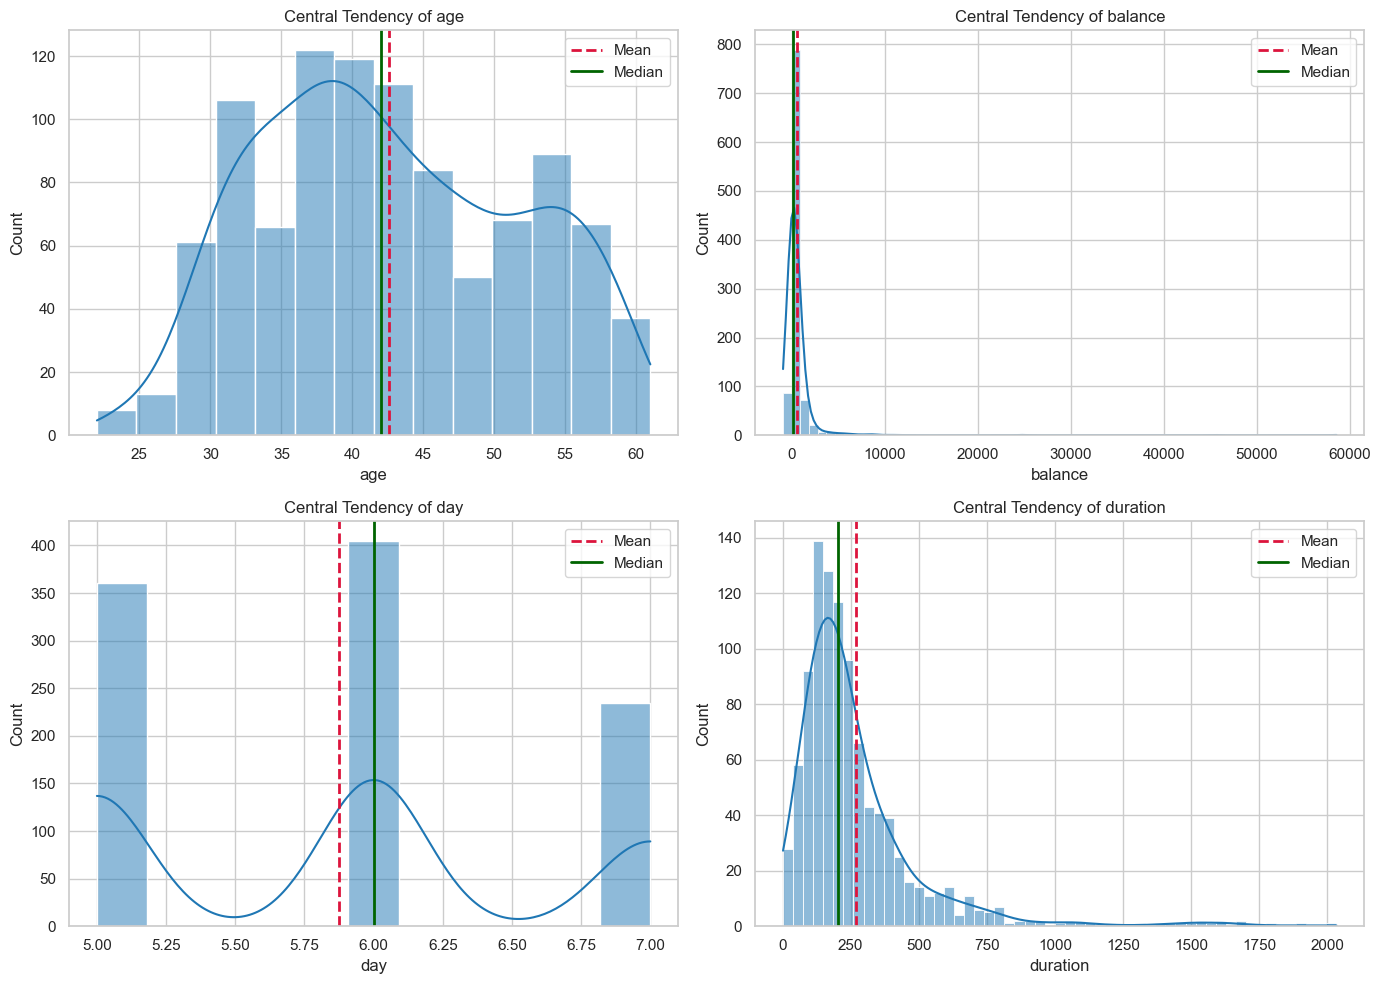

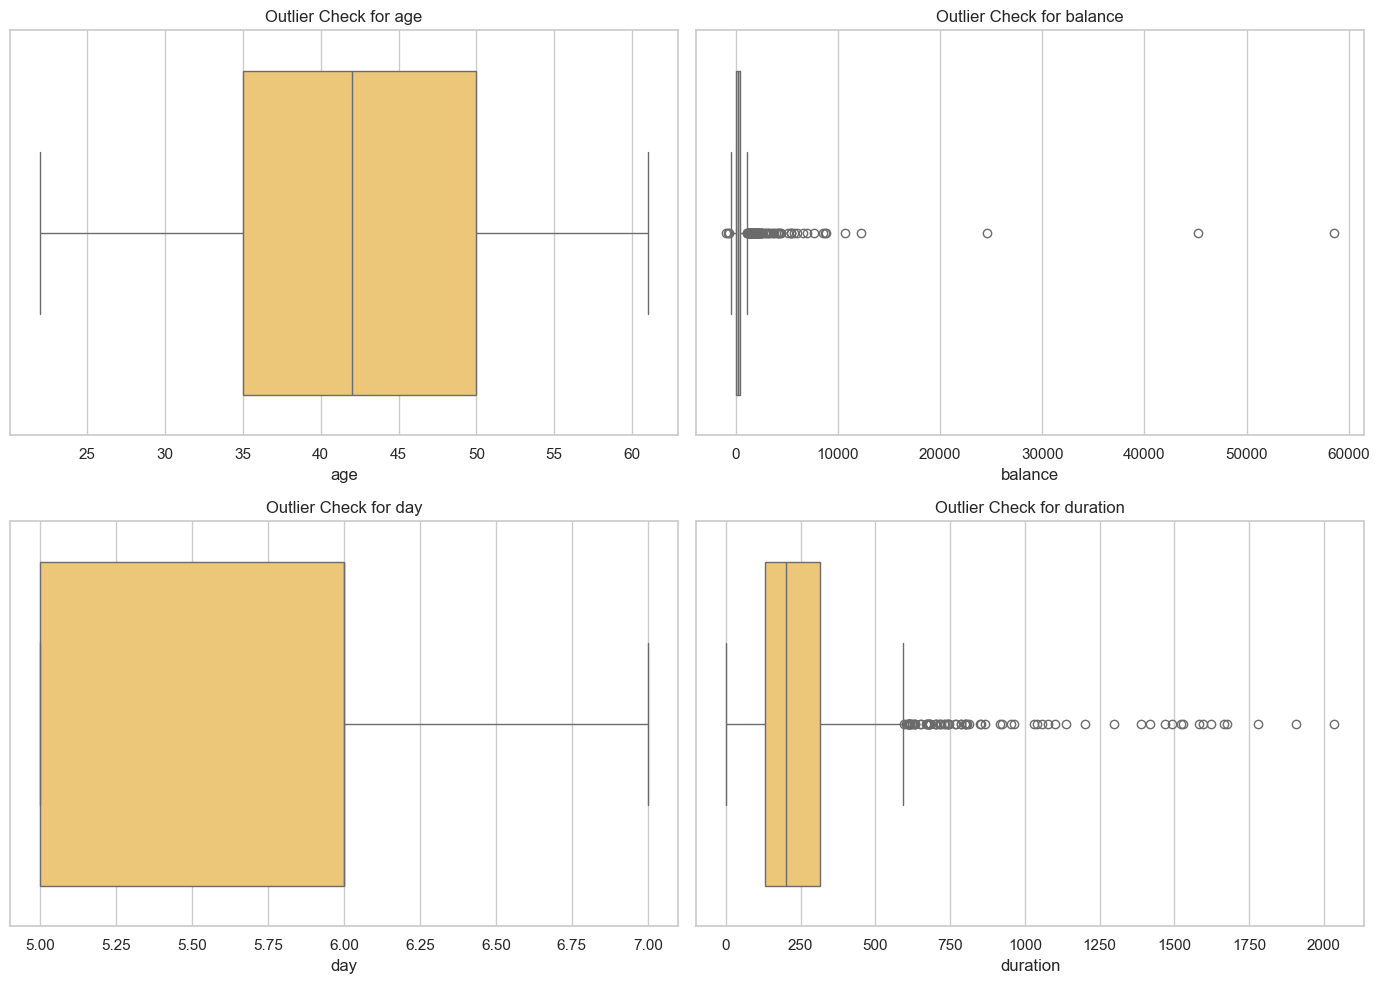

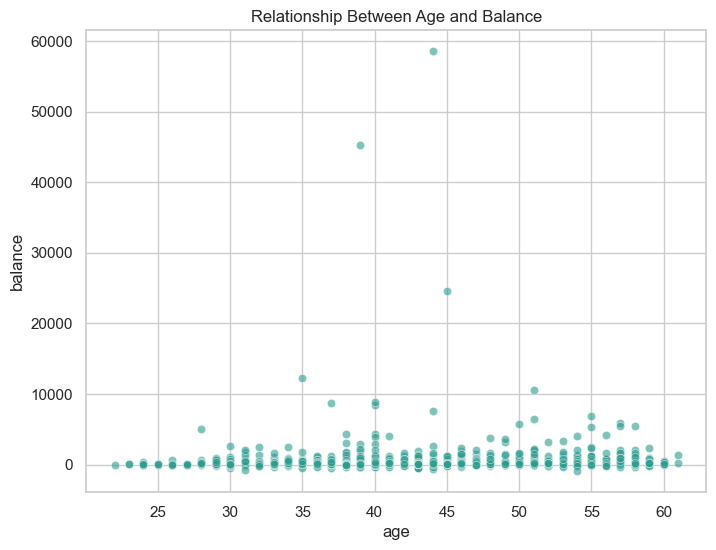

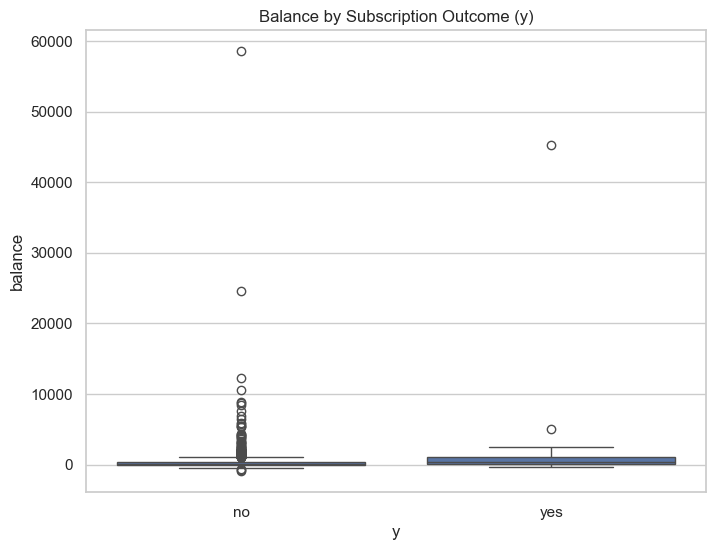

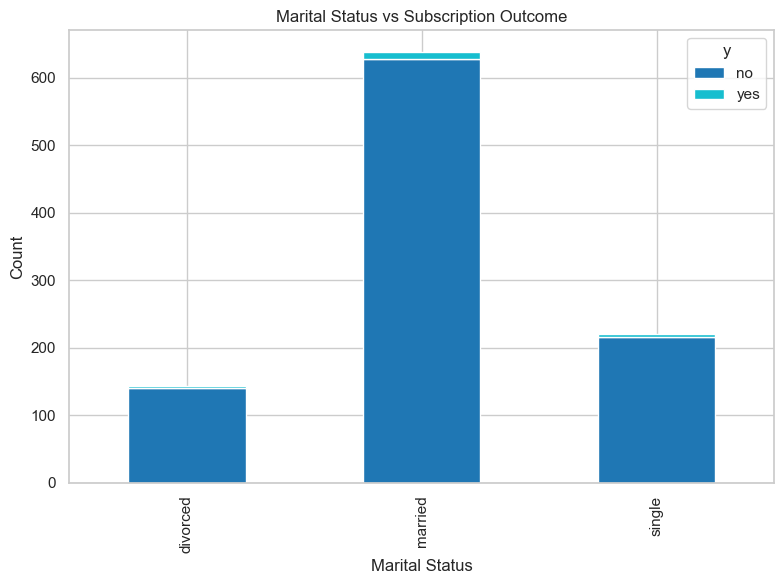

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

# Load the CSV
df = pd.read_csv('dataset.csv')

numeric_cols = ['age', 'balance', 'day', 'duration']
nominal_cols = ['job', 'marital', 'y']

# Keep a working copy for visualization
df_vis = df.copy()

# Function to identify outliers using the IQR method
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper

outlier_counts = {}
for col in numeric_cols:
    mask, lower, upper = iqr_outlier_mask(df_vis[col])
    outlier_counts[col] = int(mask.sum())

print('Dataset shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

print('\nCentral tendency (numeric):')
central_tendency = df[numeric_cols].agg(['mean', 'median']).T
central_tendency['mode'] = [df[col].mode().iloc[0] for col in numeric_cols]
display(central_tendency)

print('\nOutlier counts by numeric column (IQR rule):')
display(pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['outlier_count']))

# 1. Central tendency: visual + numeric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#1f77b4')
    ax.axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(df[col].median(), color='darkgreen', linestyle='-', linewidth=2, label='Median')
    ax.set_title(f'Central Tendency of {col}')
    ax.legend()
plt.tight_layout()
plt.show()

# 2. Outlier identification: visual + numeric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df_vis[col], ax=ax, color='#ffcc66')
    ax.set_title(f'Outlier Check for {col}')
plt.tight_layout()
plt.show()

# 3. Relationship between two numeric variables
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_vis, x='age', y='balance', alpha=0.6, color='#2a9d8f')
plt.title('Relationship Between Age and Balance')
plt.show()

# 4. Relationship between numeric and nominal variable
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_vis, x='y', y='balance')
plt.title('Balance by Subscription Outcome (y)')
plt.show()

# 5. Relationship between two nominal variables
ct = pd.crosstab(df_vis['marital'], df_vis['y'])
ct.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='tab10')
plt.title('Marital Status vs Subscription Outcome')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='y')
plt.tight_layout()
plt.show()


In [6]:
# Compute exact group statistics used in the interpretation
median_by_y = df.groupby('y')['balance'].median()
counts_by_y = df['y'].value_counts()
marital_y = pd.crosstab(df['marital'], df['y']).assign(total=lambda x: x.sum(axis=1))
marital_y['pct_yes'] = (marital_y['yes'] / marital_y['total'] * 100).round(2)

print('median_by_y:')
print(median_by_y.to_string())
print('\ncounts_by_y:')
print(counts_by_y.to_string())
print('\nmarital distribution (counts and % yes):')
print(marital_y[['yes','no','total','pct_yes']].to_string())


median_by_y:
y
no     162.0
yes    387.0

counts_by_y:
y
no     982
yes     19

marital distribution (counts and % yes):
y         yes   no  total  pct_yes
marital                           
divorced    3  140    143     2.10
married    11  627    638     1.72
single      5  215    220     2.27


**Interpretation of EDA results**

- **Dataset:** 1001 rows × 7 columns. Numeric: `age`, `balance`, `day`, `duration`. Nominal: `job`, `marital`, `y`.

- **Central tendency (numeric):**
  - `age`: mean ≈ 42.59, median = 42, mode = 40 — roughly symmetric, centered in early-40s.
  - `balance`: mean ≈ 580.42, median = 165, mode = 0 — right-skewed (many zeros), mean pulled up by large balances.
  - `day`: mean ≈ 5.87, median = 6 — concentrated around early month days.
  - `duration`: mean ≈ 269.02, median = 202, mode = 144 — skewed right with some long calls.

- **Outliers (IQR rule):**
  - `balance`: 110 outliers — large positive balances drive skew.
  - `duration`: 75 outliers — some very long call durations.
  - `age` and `day`: 0 outliers by IQR.
  - Interpretation: outliers in `balance`/`duration` reflect a heavy-tail distribution; consider log-transform or robust statistics if modeling.

- **Numeric × Numeric (age vs balance):**
  - Scatter shows no strong linear relationship; balance is widely spread across ages, with higher balances more frequent in middle ages but not strictly age-dependent.

- **Numeric × Nominal (balance by `y`):**
  - Median `balance` for `y=no` = 162, for `y=yes` = 387 — subscribers (`y=yes`) have notably higher median balances, suggesting balance is associated with subscription outcome.

- **Nominal × Nominal (marital vs `y`):**
  - Conversion rates (`% yes`): `single` ≈ 2.27%, `divorced` ≈ 2.10%, `married` ≈ 1.72% — differences are small; overall conversion is low (19 of 1001 ≈ 1.9%).

- **Actionable notes:**
  - Consider log-scaling `balance` for modeling or use robust estimators.
  - Investigate long `duration` values — may be influential or data-quality issues.
  - `balance` appears predictive of `y`; include it in downstream models and consider interaction with `job`/`marital`.
